# **Implementing and Comparing Machine Learning Algorithms for an E-Commerce Recommendation System**

# Dataset checking

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
df=pd.read_csv("/content/ecommerce_updated.csv")
df.head()

,CustomerID,Gender,InvoiceDate,InvoiceNumber,ProductID,Quantity,Price,Total,OrderStatus,Country,...,DeviceCategory,Device,OS,DeliveryRating,ProductRating,Sales,category,Previous_Purchases,Cart_Addition_Count,Discount_Usage
0,9691,Female,1/01/2019,26088332,32,3,91.37,274.11,Completed,India,...,Computer,Laptop,Windows,2,5,274.11,Beauty,19,4,0
1,8327,Female,1/01/2019,95183269,34,1,48.24,48.24,In Process,India,...,Computer,Desktop,Windows,0,0,0.00,Sports,19,5,0
2,6801,Male,1/01/2019,44769684,64,2,35.23,70.46,Completed,United States,...,Computer,Desktop,Windows,1,2,70.46,Home,29,3,1
3,4406,Male,1/02/2019,12422351,41,2,32.33,64.66,Completed,Philippines,...,Mobile,Tablet,Windows,4,4,64.66,Sports,34,5,0
4,1966,Male,1/03/2019,84352310,20,1,81.89,81.89,Completed,Brazil,...,Computer,Laptop,Windows,5,3,81.89,Sports,34,7,1


In [3]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
InvoiceDate,0
InvoiceNumber,0
ProductID,0
Quantity,0
Price,0
Total,0
OrderStatus,0
Country,0


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df=df.drop(["CustomerID","InvoiceDate","InvoiceNumber","ProductID","DeviceCategory","Device","OS","Sales"],axis=1)

In [6]:
df.head()

,Gender,Quantity,Price,Total,OrderStatus,Country,TrafficSource,SessionDuration,DeliveryRating,ProductRating,category,Previous_Purchases,Cart_Addition_Count,Discount_Usage
0,Female,3,91.37,274.11,Completed,India,Social Media,6.54,2,5,Beauty,19,4,0
1,Female,1,48.24,48.24,In Process,India,Social Media,5.01,0,0,Sports,19,5,0
2,Male,2,35.23,70.46,Completed,United States,Paid Advertisment,0.10,1,2,Home,29,3,1
3,Male,2,32.33,64.66,Completed,Philippines,Social Media,1.95,4,4,Sports,34,5,0
4,Male,1,81.89,81.89,Completed,Brazil,Organic Search,9.15,5,3,Sports,34,7,1


In [7]:
df['ProductRating'].value_counts()

,count
ProductRating,
0,1354
5,1123
4,690
3,330
2,83
1,19


# Exploratory Data Analysis

category
Beauty         483
Electronics    478
Sports         440
Clothing       434
Home           410
Name: count, dtype: int64


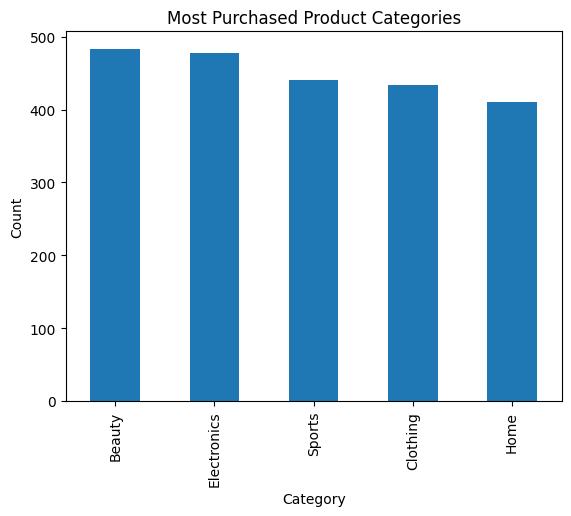

In [8]:
purchased_df = df[df["OrderStatus"] == "Completed"]

most_purchased = purchased_df["category"].value_counts()
print(most_purchased)

plt.figure()
most_purchased.plot(kind='bar')
plt.title("Most Purchased Product Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()


category
Beauty         2.771812
Electronics    2.765668
Clothing       2.632565
Sports         2.565807
Home           2.521045
Name: ProductRating, dtype: float64


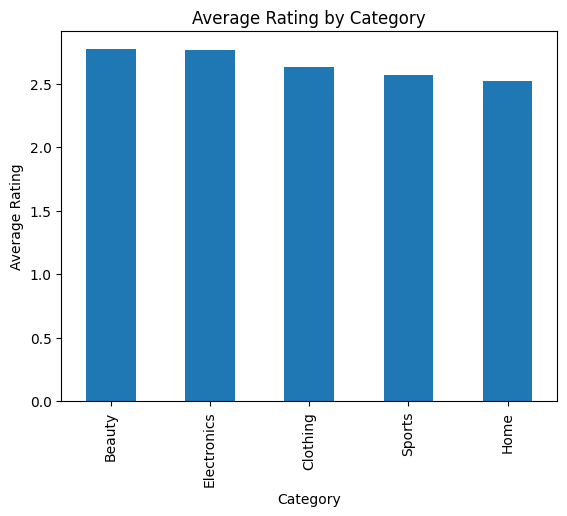

In [9]:
avg_rating = df.groupby("category")["ProductRating"].mean().sort_values(ascending=False)
print(avg_rating)

plt.figure()
avg_rating.plot(kind='bar')
plt.title("Average Rating by Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.show()

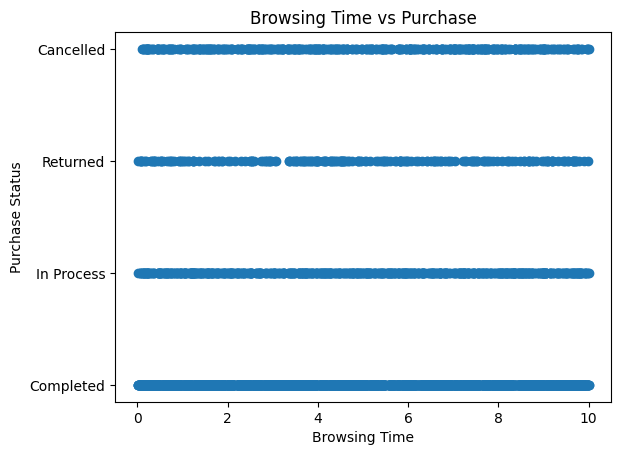

In [10]:
plt.figure()
plt.scatter(df["SessionDuration"], df["OrderStatus"])
plt.title("Browsing Time vs Purchase")
plt.xlabel("Browsing Time")
plt.ylabel("Purchase Status")
plt.show()

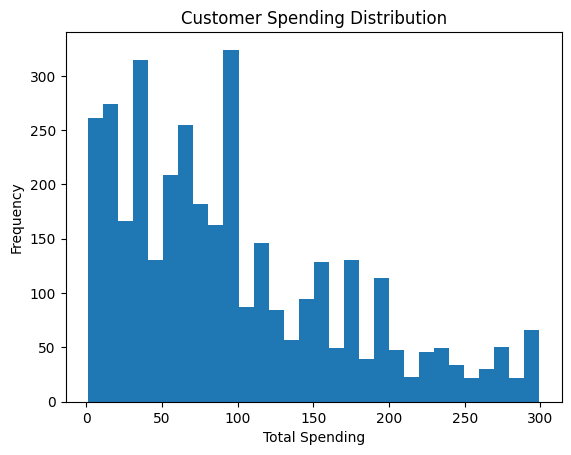

In [11]:
plt.figure()
df["Total"].plot(kind='hist', bins=30)
plt.title("Customer Spending Distribution")
plt.xlabel("Total Spending")
plt.show()

Discount_Usage
0    24.391329
1    24.583105
Name: Previous_Purchases, dtype: float64


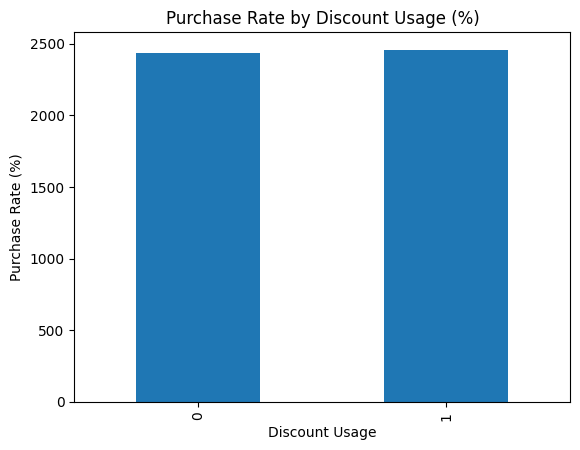

In [12]:
discount_purchase = df.groupby("Discount_Usage")["Previous_Purchases"].mean()
print(discount_purchase)

discount_purchase = discount_purchase * 100

plt.figure()
discount_purchase.plot(kind='bar')
plt.title("Purchase Rate by Discount Usage (%)")
plt.xlabel("Discount Usage")
plt.ylabel("Purchase Rate (%)")
plt.show()

In [13]:
df.head()

,Gender,Quantity,Price,Total,OrderStatus,Country,TrafficSource,SessionDuration,DeliveryRating,ProductRating,category,Previous_Purchases,Cart_Addition_Count,Discount_Usage
0,Female,3,91.37,274.11,Completed,India,Social Media,6.54,2,5,Beauty,19,4,0
1,Female,1,48.24,48.24,In Process,India,Social Media,5.01,0,0,Sports,19,5,0
2,Male,2,35.23,70.46,Completed,United States,Paid Advertisment,0.10,1,2,Home,29,3,1
3,Male,2,32.33,64.66,Completed,Philippines,Social Media,1.95,4,4,Sports,34,5,0
4,Male,1,81.89,81.89,Completed,Brazil,Organic Search,9.15,5,3,Sports,34,7,1


# Regression — Rating Prediction

In [94]:
X=df.drop("ProductRating",axis=1)
y=df["ProductRating"]


In [15]:
X

,Gender,Quantity,Price,Total,OrderStatus,Country,TrafficSource,SessionDuration,DeliveryRating,category,Previous_Purchases,Cart_Addition_Count,Discount_Usage
0,Female,3,91.37,274.11,Completed,India,Social Media,6.54,2,Beauty,19,4,0
1,Female,1,48.24,48.24,In Process,India,Social Media,5.01,0,Sports,19,5,0
2,Male,2,35.23,70.46,Completed,United States,Paid Advertisment,0.10,1,Home,29,3,1
3,Male,2,32.33,64.66,Completed,Philippines,Social Media,1.95,4,Sports,34,5,0
4,Male,1,81.89,81.89,Completed,Brazil,Organic Search,9.15,5,Sports,34,7,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3594,Male,3,32.34,97.02,In Process,Germany,Organic Search,9.42,0,Electronics,36,1,0
3595,Male,1,33.11,33.11,Completed,United States,Social Media,9.78,4,Electronics,47,2,1
3596,Male,1,33.11,33.11,Completed,India,Organic Search,9.80,3,Sports,32,9,0
3597,Male,2,73.53,147.06,In Process,South Korea,Paid Advertisment,6.53,0,Electronics,27,8,0


In [16]:
y

,ProductRating
0,5
1,0
2,2
3,4
4,3
...,...
3594,0
3595,5
3596,5
3597,0


In [95]:
X = pd.get_dummies(X, drop_first=True)

In [18]:
X

,Quantity,Price,Total,SessionDuration,DeliveryRating,Previous_Purchases,Cart_Addition_Count,Discount_Usage,Gender_Male,OrderStatus_Completed,...,Country_Turkey,Country_United Kingdom,Country_United States,Country_Vietnam,TrafficSource_Paid Advertisment,TrafficSource_Social Media,category_Clothing,category_Electronics,category_Home,category_Sports
0,3,91.37,274.11,6.54,2,19,4,0,False,True,...,False,False,False,False,False,True,False,False,False,False
1,1,48.24,48.24,5.01,0,19,5,0,False,False,...,False,False,False,False,False,True,False,False,False,True
2,2,35.23,70.46,0.10,1,29,3,1,True,True,...,False,False,True,False,True,False,False,False,True,False
3,2,32.33,64.66,1.95,4,34,5,0,True,True,...,False,False,False,False,False,True,False,False,False,True
4,1,81.89,81.89,9.15,5,34,7,1,True,True,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3594,3,32.34,97.02,9.42,0,36,1,0,True,False,...,False,False,False,False,False,False,False,True,False,False
3595,1,33.11,33.11,9.78,4,47,2,1,True,True,...,False,False,True,False,False,True,False,True,False,False
3596,1,33.11,33.11,9.80,3,32,9,0,True,True,...,False,False,False,False,False,False,False,False,False,True
3597,2,73.53,147.06,6.53,0,27,8,0,True,False,...,False,False,False,False,True,False,False,True,False,False


In [96]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [20]:
X_train

,Quantity,Price,Total,SessionDuration,DeliveryRating,Previous_Purchases,Cart_Addition_Count,Discount_Usage,Gender_Male,OrderStatus_Completed,...,Country_Turkey,Country_United Kingdom,Country_United States,Country_Vietnam,TrafficSource_Paid Advertisment,TrafficSource_Social Media,category_Clothing,category_Electronics,category_Home,category_Sports
1558,2,89.85,179.70,8.02,0,13,6,1,True,False,...,True,False,False,False,False,True,False,True,False,False
2285,2,99.72,199.44,6.02,5,11,0,0,True,True,...,False,False,False,False,False,True,False,False,False,False
3450,2,33.28,66.56,4.59,4,26,0,0,True,True,...,False,False,False,False,False,False,False,True,False,False
2188,1,78.78,78.78,1.27,4,24,5,1,True,True,...,False,False,False,False,True,False,False,True,False,False
2557,2,26.03,52.06,7.13,0,1,7,0,True,False,...,False,False,False,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3024,1,38.95,38.95,0.17,0,27,5,0,False,False,...,False,False,False,False,False,False,False,False,False,True
351,1,67.18,67.18,0.55,0,31,6,1,True,False,...,False,False,True,False,False,False,True,False,False,False
1246,3,67.48,202.44,5.10,3,9,4,0,True,True,...,False,False,False,False,False,True,False,False,True,False
1488,2,50.48,100.96,1.08,0,25,7,1,False,False,...,False,False,False,False,False,True,False,False,False,True


In [97]:
scale=StandardScaler()
X_train=scale.fit_transform(X_train)
X_test=scale.transform(X_test)

In [22]:
lin_reg=LinearRegression()
lin_reg.fit(X_train,y_train)

LinearRegression()

In [23]:
y_pred=lin_reg.predict(X_test)

In [24]:
rid_reg=Ridge()
rid_reg.fit(X_train,y_train)
y_pred_rid=rid_reg.predict(X_test)

In [25]:
print("Linear_regression")
print("MSE",mean_squared_error(y_test,y_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))
print("MAE",mean_absolute_error(y_test,y_pred))
print("R2_score",r2_score(y_test,y_pred))

Linear_regression
MSE 0.5121727516081496
RMSE 0.7156624564752224
MAE 0.49393259617374463
R2_score 0.8922651179281038


In [26]:
print("Ridge_regression")
print("MSE",mean_squared_error(y_test,y_pred_rid))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred_rid)))
print("MAE",mean_absolute_error(y_test,y_pred_rid))
print("R2_score",r2_score(y_test,y_pred_rid))


Ridge_regression
MSE 0.5124894362728877
RMSE 0.7158836750987465
MAE 0.4940350874870682
R2_score 0.892198503714633


In [27]:
rfr_model=RandomForestRegressor()
rfr_model.fit(X_train,y_train)
y_pred_rfr=rfr_model.predict(X_test)

In [28]:
print("Random_forest_regression")
print("MSE",mean_squared_error(y_test,y_pred_rfr))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred_rfr)))
print("MAE",mean_absolute_error(y_test,y_pred_rfr))
print("R2_score",r2_score(y_test,y_pred_rfr))

Random_forest_regression
MSE 0.5318293055555555
RMSE 0.7292662789102178
MAE 0.47504166666666664
R2_score 0.888130386990516


In [29]:
dtr_model=DecisionTreeRegressor()
dtr_model.fit(X_train,y_train)
y_pred_dtr=dtr_model.predict(X_test)

In [30]:
print("Decision_tree_regression")
print("MSE",mean_squared_error(y_test,y_pred_dtr))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred_dtr)))
print("MAE",mean_absolute_error(y_test,y_pred_dtr))
print("R2_score",r2_score(y_test,y_pred_dtr))

Decision_tree_regression
MSE 0.9625
RMSE 0.9810708435174292
MAE 0.5486111111111112
R2_score 0.7975393582172946


In [31]:
ridge = Ridge()

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100],   # main hyperparameter
    'fit_intercept': [True, False],
    'solver': ['auto', 'svd', 'cholesky', 'lsqr']
}

grid = GridSearchCV(ridge, param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best R2 Score:", grid.best_score_)

Best Params: {'alpha': 1, 'fit_intercept': True, 'solver': 'lsqr'}
Best R2 Score: 0.892131933201403


In [98]:
bst_model = Ridge(alpha=1, fit_intercept=True, solver='lsqr')
bst_model.fit(X_train, y_train)
y_pred_bst = bst_model.predict(X_test)
print("Best Model")
print("MSE", mean_squared_error(y_test, y_pred_bst))
print("RMSE", np.sqrt(mean_squared_error(y_test, y_pred_bst)))
print("MAE", mean_absolute_error(y_test, y_pred_bst))
print("R2_score", r2_score(y_test, y_pred_bst))

Best Model
MSE 0.5126096119313734
RMSE 0.7159676053644979
MAE 0.4942902537976301
R2_score 0.8921732249188473


# Classification — Purchase Likelihood Prediction

In [32]:
df.head()

,Gender,Quantity,Price,Total,OrderStatus,Country,TrafficSource,SessionDuration,DeliveryRating,ProductRating,category,Previous_Purchases,Cart_Addition_Count,Discount_Usage
0,Female,3,91.37,274.11,Completed,India,Social Media,6.54,2,5,Beauty,19,4,0
1,Female,1,48.24,48.24,In Process,India,Social Media,5.01,0,0,Sports,19,5,0
2,Male,2,35.23,70.46,Completed,United States,Paid Advertisment,0.10,1,2,Home,29,3,1
3,Male,2,32.33,64.66,Completed,Philippines,Social Media,1.95,4,4,Sports,34,5,0
4,Male,1,81.89,81.89,Completed,Brazil,Organic Search,9.15,5,3,Sports,34,7,1


In [33]:
df['OrderStatus'].value_counts()

,count
OrderStatus,
Completed,2245
In Process,665
Cancelled,457
Returned,232


In [34]:
df['OrderStatus']=df['OrderStatus'].map({'Completed':1,'Cancelled':0,'In Process':0,'Returned':0})

In [35]:
df['OrderStatus'].value_counts()

,count
OrderStatus,
1,2245
0,1354


In [99]:
X=df.drop(['OrderStatus','ProductRating','DeliveryRating',],axis=1)
y=df['OrderStatus']

In [100]:
X=pd.get_dummies(X,drop_first=True)

In [101]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [102]:
X_test

,Quantity,Price,Total,SessionDuration,Previous_Purchases,Cart_Addition_Count,Discount_Usage,Cluster,Gender_Male,Country_Australia,...,Country_Turkey,Country_United Kingdom,Country_United States,Country_Vietnam,TrafficSource_Paid Advertisment,TrafficSource_Social Media,category_Clothing,category_Electronics,category_Home,category_Sports
2283,2,6.32,12.64,9.75,8,5,0,0,True,False,...,False,False,False,False,False,True,False,True,False,False
1636,1,91.37,91.37,4.34,18,0,0,2,True,False,...,False,False,False,False,True,False,True,False,False,False
2516,2,5.32,10.64,7.68,12,7,1,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1424,1,56.74,56.74,6.91,21,9,1,0,True,False,...,False,False,False,False,False,False,False,False,True,False
2048,2,19.66,39.32,7.77,34,7,1,0,False,False,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1364,1,72.93,72.93,5.55,18,2,0,2,False,False,...,False,True,False,False,False,False,False,False,False,True
2162,3,3.55,10.65,9.36,25,6,1,0,False,False,...,False,False,False,False,False,False,False,False,True,False
3067,1,70.34,70.34,1.36,25,1,1,1,True,False,...,False,False,False,False,True,False,True,False,False,False
1811,3,28.56,85.68,7.84,33,2,1,0,True,False,...,False,False,False,False,False,False,False,False,False,True


In [40]:
y_train

,OrderStatus
2905,0
1067,0
815,0
305,1
1198,1
...,...
669,0
642,0
2952,1
138,1


In [103]:
model=LogisticRegression(max_iter=500)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [42]:
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.17      0.00      0.01       271
           1       0.62      0.99      0.76       449

    accuracy                           0.62       720
   macro avg       0.39      0.50      0.39       720
weighted avg       0.45      0.62      0.48       720

0.6180555555555556


In [43]:
corr = df.corr(numeric_only=True)
print(corr['OrderStatus'].sort_values(ascending=False))

OrderStatus            1.000000
ProductRating          0.945540
DeliveryRating         0.940500
Quantity               0.022396
Previous_Purchases     0.017469
Total                  0.011994
SessionDuration        0.008338
Price                 -0.001571
Discount_Usage        -0.002477
Cart_Addition_Count   -0.008282
Name: OrderStatus, dtype: float64


In [44]:
rfc=RandomForestClassifier()
rfc.fit(X_train,y_train)
y_pred_rfc=rfc.predict(X_test)

In [45]:
print(classification_report(y_test,y_pred_rfc))
print(accuracy_score(y_test,y_pred_rfc))

              precision    recall  f1-score   support

           0       0.35      0.11      0.17       271
           1       0.62      0.88      0.73       449

    accuracy                           0.59       720
   macro avg       0.49      0.49      0.45       720
weighted avg       0.52      0.59      0.52       720

0.5888888888888889


In [46]:
param_dist = {
    'C': [0.01, 0.1, 1, 10, 100],              # Regularization strength
    'penalty': ['l1', 'l2'],                   # Regularization type
    'solver': ['liblinear', 'saga'],           # Compatible solvers
    'max_iter': [100, 200, 500, 1000]
}

In [47]:
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,                # number of random combinations
    cv=5,                     # 5-fold cross-validation
    scoring='f1',             # better than accuracy for imbalance
    random_state=42,
    n_jobs=-1
)

In [48]:
random_search.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


RandomizedSearchCV(cv=5, estimator=LogisticRegression(max_iter=500), n_jobs=-1,
                   param_distributions={'C': [0.01, 0.1, 1, 10, 100],
                                        'max_iter': [100, 200, 500, 1000],
                                        'penalty': ['l1', 'l2'],
                                        'solver': ['liblinear', 'saga']},
                   random_state=42, scoring='f1')

In [49]:
y_pred_ran=random_search.predict(X_test)

In [50]:
print(classification_report(y_test,y_pred_ran))
print(accuracy_score(y_test,y_pred_ran))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       271
           1       0.62      1.00      0.77       449

    accuracy                           0.62       720
   macro avg       0.31      0.50      0.38       720
weighted avg       0.39      0.62      0.48       720

0.6236111111111111


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [51]:
print(random_search.best_params_)

{'solver': 'saga', 'penalty': 'l2', 'max_iter': 1000, 'C': 0.1}


In [104]:
tune_model=LogisticRegression(C=0.1, max_iter=1000, penalty='l2', solver='saga')
tune_model.fit(X_train,y_train)
y_pred_tune=tune_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [105]:
print(classification_report(y_test,y_pred_tune))
print(accuracy_score(y_test,y_pred_tune))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       271
           1       0.62      1.00      0.77       449

    accuracy                           0.62       720
   macro avg       0.31      0.50      0.38       720
weighted avg       0.39      0.62      0.48       720

0.6222222222222222


# Clustering — Customer Segmentation

In [52]:
df.head()

,Gender,Quantity,Price,Total,OrderStatus,Country,TrafficSource,SessionDuration,DeliveryRating,ProductRating,category,Previous_Purchases,Cart_Addition_Count,Discount_Usage
0,Female,3,91.37,274.11,1,India,Social Media,6.54,2,5,Beauty,19,4,0
1,Female,1,48.24,48.24,0,India,Social Media,5.01,0,0,Sports,19,5,0
2,Male,2,35.23,70.46,1,United States,Paid Advertisment,0.10,1,2,Home,29,3,1
3,Male,2,32.33,64.66,1,Philippines,Social Media,1.95,4,4,Sports,34,5,0
4,Male,1,81.89,81.89,1,Brazil,Organic Search,9.15,5,3,Sports,34,7,1


In [106]:
X=df[['SessionDuration','Previous_Purchases','Total','Discount_Usage']]

In [107]:
scale=StandardScaler()
X_scaled=scale.fit_transform(X)


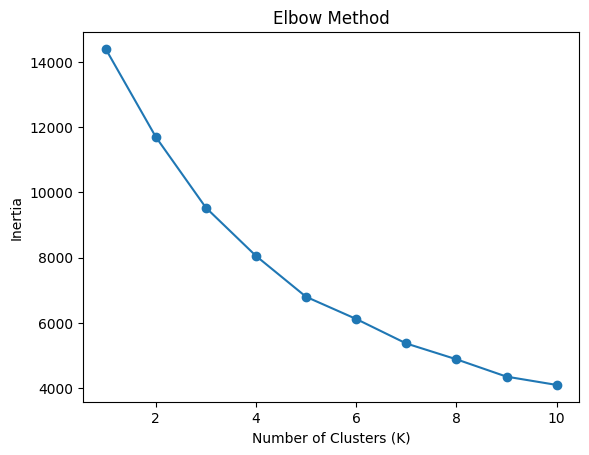

In [80]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [81]:
silhouette_scores = []
K_range = range(2, 11)   # start from 2 (IMPORTANT)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

    print(f"K={k}, Silhouette Score={score}")

K=2, Silhouette Score=0.18661397582926062
K=3, Silhouette Score=0.21658239242301863
K=4, Silhouette Score=0.22528031351411368
K=5, Silhouette Score=0.2517892207700879
K=6, Silhouette Score=0.24541585244216985
K=7, Silhouette Score=0.26166882481224946
K=8, Silhouette Score=0.2621823926229117
K=9, Silhouette Score=0.2757992627990346
K=10, Silhouette Score=0.27712217785135546


In [82]:
kmeans = KMeans(n_clusters=4, random_state=42)

In [83]:
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [84]:
df.head()

,Gender,Quantity,Price,Total,OrderStatus,Country,TrafficSource,SessionDuration,DeliveryRating,ProductRating,category,Previous_Purchases,Cart_Addition_Count,Discount_Usage,Cluster
0,Female,3,91.37,274.11,1,India,Social Media,6.54,2,5,Beauty,19,4,0,3
1,Female,1,48.24,48.24,0,India,Social Media,5.01,0,0,Sports,19,5,0,2
2,Male,2,35.23,70.46,1,United States,Paid Advertisment,0.10,1,2,Home,29,3,1,1
3,Male,2,32.33,64.66,1,Philippines,Social Media,1.95,4,4,Sports,34,5,0,2
4,Male,1,81.89,81.89,1,Brazil,Organic Search,9.15,5,3,Sports,34,7,1,0


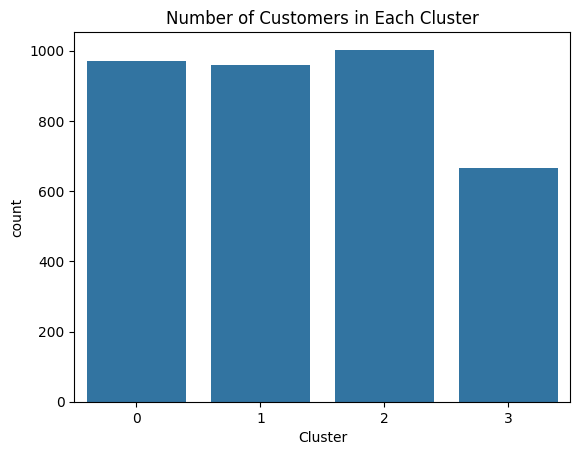

In [87]:
import seaborn as sns

sns.countplot(x='Cluster', data=df)
plt.title('Number of Customers in Each Cluster')
plt.show()

# **Final Comparison**


In Regression for Rating:
    Ridge Regression better among other Regression model



In classification for purchase:
    Logistic Regression is better among other Classification model.



In Clustering for customer segmentaion:
    In this case we use the Kmeans clustering model.







**Which regression model predicted ratings better.**

Ridge regression is best model to predict to the rating with 0.89 R2score higher than the other model.

**How well logistic regression predicted purchase likelihood.**

Logistic Regression achieved an accuracy of ~62% and indicating a good ability to distinguish between purchasing and non-purchasing customers.

**How many customer segments were identified using K-Means.**

4 customer segments

**Which segment is most valuable to the business.**

Cluster 4 (High value segment )


1.   High Spending
2.   High session duration
3.   High engagement with products
4.   More purchases




**Which features influenced customer behavior.**

* Session Duration
* Price
* Previous Purchases
* Discount Usage
* Product Rating





**How these models can improve recommendations.**

* Regression → predict ratings → recommend highly rated products
* Classification → predict purchase → target likely buyers
* Clustering → segment users → personalized marketing

**How evaluation metrics support business decision-making.**

Evaluation metrics such as R2 score, confusion matrix and silhouette score ensure that models are reliable and actionable, enabling better customer targeting and improved decision-making.

# **Final Summary**

Linear Regression performed best for rating prediction, while Logistic Regression effectively predicted purchase likelihood with good accuracy and confusion matrix. K-Means clustering identified 4 meaningful customer segments, with the high-value segment contributing most to revenue. Key behavioral features included session duration, price, and previous purchases. These models together enable personalized recommendations, targeted marketing, and data-driven business decisions, supported by strong evaluation metrics.